In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

df = pd.read_csv('../data/cleaned/city_day_cleaned.csv')
print("✅ Data loaded:", df.shape)

✅ Data loaded: (24850, 21)


In [2]:
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
            'Benzene', 'Toluene', 'Year', 'Month', 'Day',
            'City_Encoded', 'Season_Encoded']
target = 'AQI'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (24850, 16)
Target shape: (24850,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (19880, 16) Test: (4970, 16)


In [4]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("--- Random Forest Results ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

--- Random Forest Results ---
MAE:  20.83
RMSE: 40.42
R²:   0.9108


In [5]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Results ---")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²:   {r2_xgb:.4f}")

--- XGBoost Results ---
MAE:  20.58
RMSE: 44.73
R²:   0.8908


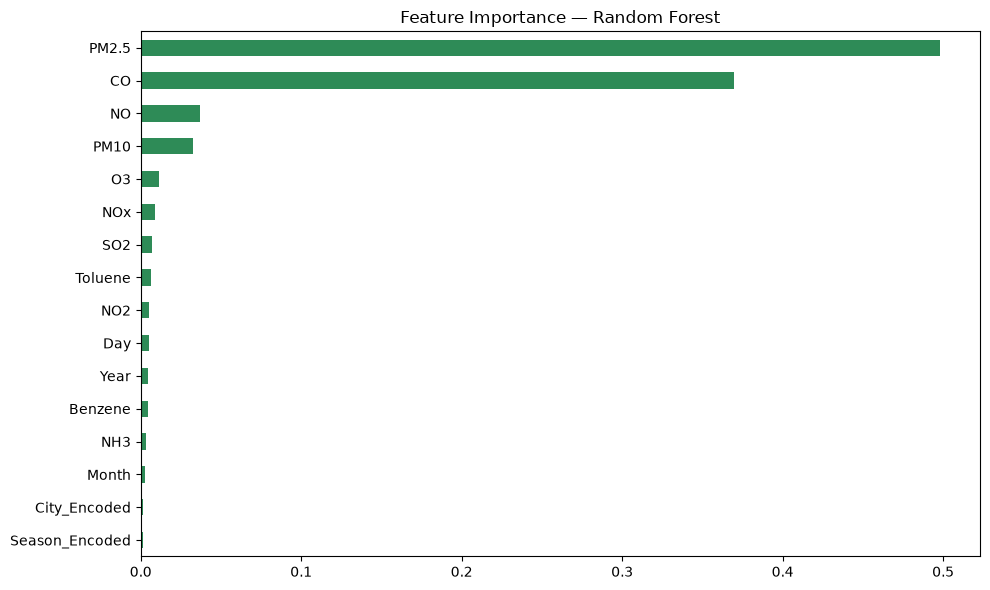

PM2.5             0.498073
CO                0.369506
NO                0.036981
PM10              0.032652
O3                0.011576
NOx               0.009147
SO2               0.007337
Toluene           0.006619
NO2               0.005348
Day               0.005018
Year              0.004535
Benzene           0.004413
NH3               0.003221
Month             0.002802
City_Encoded      0.001636
Season_Encoded    0.001136
dtype: float64


In [6]:
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='barh', color='seagreen')
plt.title('Feature Importance — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance)

In [7]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [mae, mae_xgb],
    'RMSE': [rmse, rmse_xgb],
    'R2 Score': [r2, r2_xgb]
})
print(results)
results.to_csv('../reports/model_comparison.csv', index=False)

           Model        MAE       RMSE  R2 Score
0  Random Forest  20.830869  40.418785  0.910782
1        XGBoost  20.581872  44.725174  0.890758


In [8]:
# Pick whichever has higher R2 — likely XGBoost
best_model = xgb_model if r2_xgb > r2 else rf_model
best_name = 'xgboost' if r2_xgb > r2 else 'random_forest'

joblib.dump(best_model, f'../models/aqi_{best_name}_model.pkl')
print(f"✅ Best model saved: {best_name}")

✅ Best model saved: random_forest


In [9]:
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
import time

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("--- 5-Fold Cross-Validation (Random Forest) ---")
print("R² per fold:", cv_scores.round(4))
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

--- 5-Fold Cross-Validation (Random Forest) ---
R² per fold: [0.9089 0.883  0.9181 0.916  0.9091]
Mean R²: 0.9070
Std Dev: 0.0125


In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use a smaller grid first to keep runtime reasonable
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,                    # 3-fold to keep it faster
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f"\n✅ Tuning completed in {(end-start)/60:.1f} minutes")
print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Tuning completed in 895.5 minutes
Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R² Score: 0.9037688651707843


In [11]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("--- Tuned Random Forest Results ---")
print(f"MAE:  {mae_tuned:.2f}")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"R²:   {r2_tuned:.4f}")

print("\n--- Comparison: Before vs After Tuning ---")
print(f"Before tuning → R²: {r2:.4f}")
print(f"After tuning  → R²: {r2_tuned:.4f}")
print(f"Improvement: {(r2_tuned - r2)*100:.2f}%")

--- Tuned Random Forest Results ---
MAE:  20.52
RMSE: 40.68
R²:   0.9096

--- Comparison: Before vs After Tuning ---
Before tuning → R²: 0.9108
After tuning  → R²: 0.9096
Improvement: -0.12%


In [12]:
joblib.dump(best_rf, '../models/aqi_random_forest_model.pkl')
print("✅ Tuned Random Forest model saved (replaces previous version)")

✅ Tuned Random Forest model saved (replaces previous version)


In [13]:
results_final = pd.DataFrame({
    'Model': ['Random Forest (default)', 'Random Forest (tuned)', 'XGBoost', 'LSTM'],
    'R2 Score': [r2, r2_tuned, r2_xgb, r2_lstm if 'r2_lstm' in dir() else 0.59],
    'Cross-Val Mean R2': [cv_scores.mean(), grid_search.best_score_, None, None]
})
print(results_final)
results_final.to_csv('../reports/final_model_comparison.csv', index=False)

                     Model  R2 Score  Cross-Val Mean R2
0  Random Forest (default)  0.910782           0.907025
1    Random Forest (tuned)  0.909614           0.903769
2                  XGBoost  0.890758                NaN
3                     LSTM  0.590000                NaN


In [14]:
import shap
import matplotlib.pyplot as plt

# Use the default RF model (confirmed best)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
print("✅ SHAP values computed")

✅ SHAP values computed


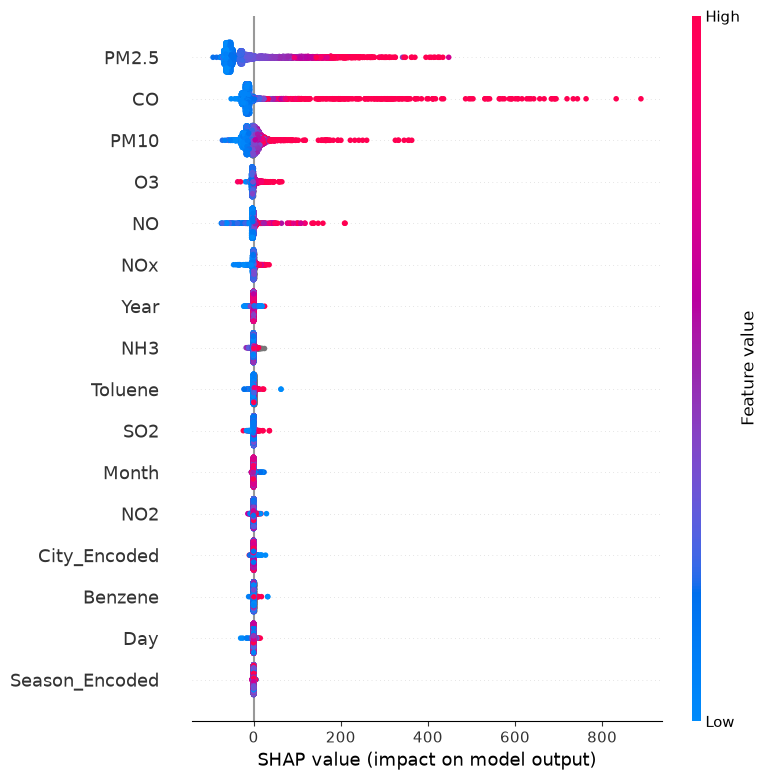

✅ SHAP summary plot saved


In [15]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('../reports/11_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved")

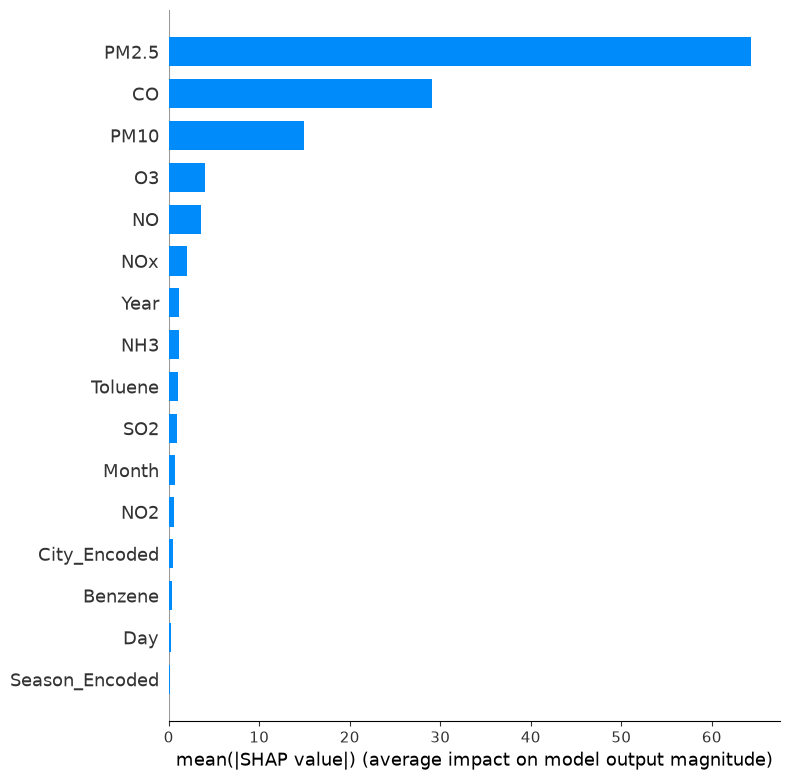

✅ SHAP bar plot saved


In [16]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features, 
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../reports/12_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved")

Actual AQI: 141.0
Predicted AQI: 100.38


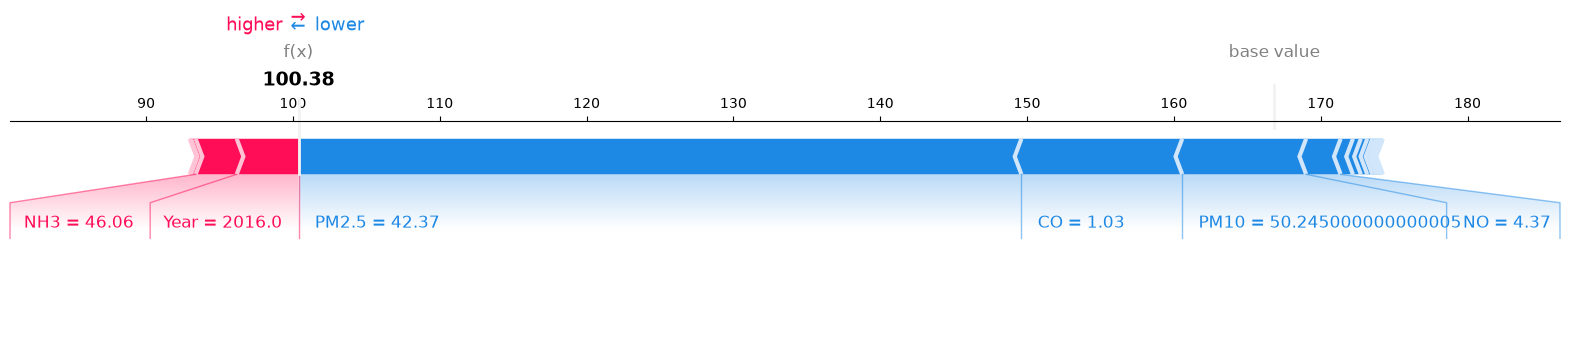

✅ SHAP force plot saved


In [17]:
# Explain the first test sample
shap.initjs()
sample_idx = 0
print("Actual AQI:", y_test.iloc[sample_idx])
print("Predicted AQI:", rf_model.predict(X_test.iloc[[sample_idx]])[0].round(2))

# Save force plot as HTML
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    feature_names=features,
    matplotlib=True,
    show=False
)
plt.savefig('../reports/13_shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP force plot saved")